# Baseline correction (`detect_flat_offsets`)

This notebook is **only** one step of the full snow-depth cleaning pipeline—the **piecewise baseline** (`detect_flat_offsets`) on segments of low variance. 

1. Point **CSV** to a file with a `date` column and **one** numeric series (or several; then set **`COL`**). The bundled example **`SD_ValleOlivares_05706003.csv`** is for reproducibility; other series prepared upstream work the same way.
2. **Re-run the config cell** whenever you change the CSV so an old **`COL`** is not reused from another file in the kernel.
3. **`COL = None`** auto-detects the value column only when **one** numeric column beside `date`; if there are multiple, set **`COL`** explicitly.
4. Tune **Y** limits, optional **date window**, and **`KW_FLAT`**, then run all cells **in order**.

Keep **`sd_ground_baseline.py`** next to this notebook (or set **`REPO`** in the code cell below). Leading nulls in the value column are dropped unless **`TRIM_TO_FIRST_VALID = False`**.


In [28]:
%matplotlib inline
from pathlib import Path
import sys

REPO = Path.cwd()
if (REPO / "sd_ground_baseline.py").is_file():
    sys.path.insert(0, str(REPO))
else:
    # If the kernel cwd is wrong, set REPO to your sd_cleaning path:
    # REPO = Path("/path/to/sd_cleaning"); sys.path.insert(0, str(REPO))
    pass

if "sd_ground_baseline" in sys.modules:
    del sys.modules["sd_ground_baseline"]

from sd_ground_baseline import (
    detect_flat_offsets,
    filter_by_date_range,
    trim_dataframe_to_first_valid_value,
    visualize_baseline_from_csv,
)

In [29]:
# --- Config ---
# Re-run this cell after changing CSV so COL is not stale from a previous run.
CSV = REPO / "SD_ValleOlivares_05706003.csv"  # Example: Valle Olivares (05706003), column name matches station id; COL = None
COL = None  # or e.g. "05706003" if several numeric columns exist
DATE_COL = "date"

KW_FLAT = dict(
    window=7,
    var_thr=1.0,
    tol=0.5,
    drift_thr=0.5,
    snow_thr=5.0,
    backfill_first=True,
)

# Y limits (cm); exact when both bounds are set. Use None to autoscale that axis.
Y_LIM_SNOW = (-10, 100)
Y_LIM_OFFSET = (None, None)

# Optional date window: limits rows before the correction (good for zooming a season). None = use full (trimmed) series.
DATE_START = None  # e.g. "2018-04-01" to zoom; None = use full (trimmed) series
DATE_END = None    # e.g. "2019-03-31"  (inclusive, day resolution)

TRIM_TO_FIRST_VALID = True
SAVEFIG = None  # e.g. REPO / "baseline.png"


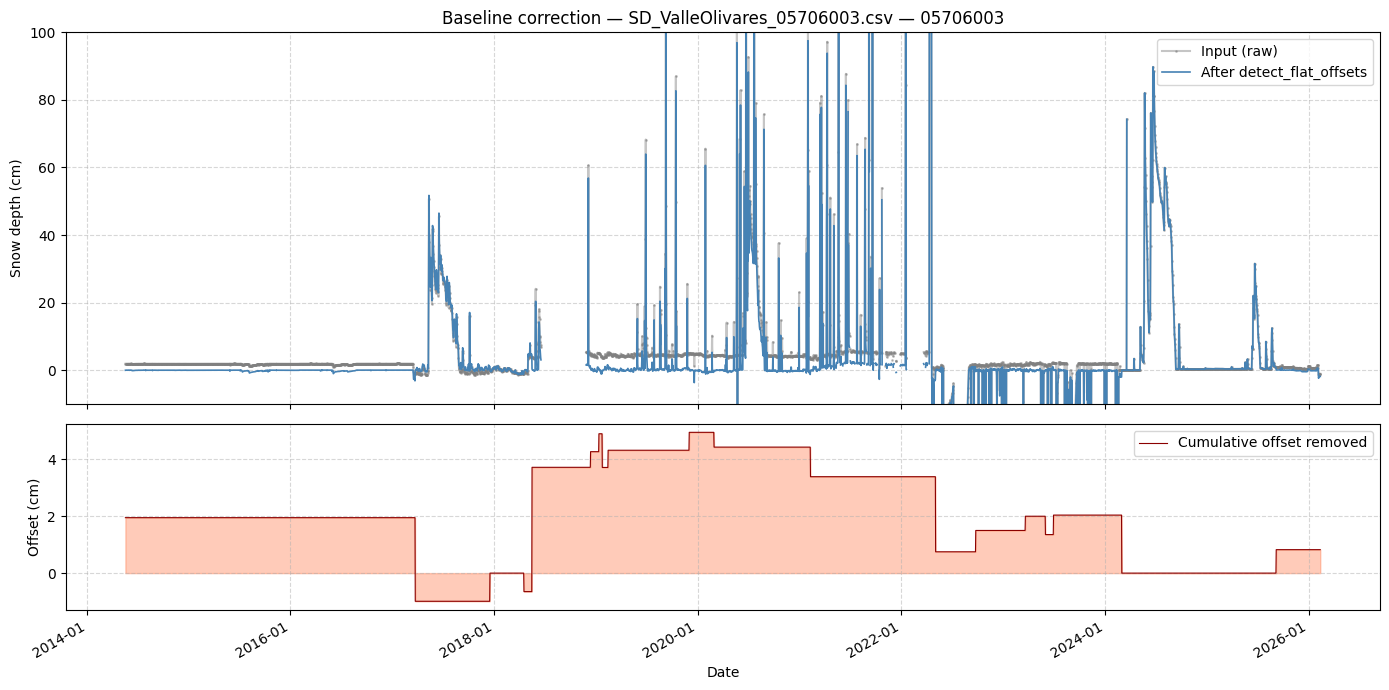

In [30]:
visualize_baseline_from_csv(
    str(CSV.resolve()),
    col=COL,
    date_col=DATE_COL,
    **KW_FLAT,

    savefig=str(SAVEFIG) if SAVEFIG else None,
    y_lim_snow=Y_LIM_SNOW,
    y_lim_offset=Y_LIM_OFFSET,
    trim_to_first_valid=TRIM_TO_FIRST_VALID,
    date_start=DATE_START,
    date_end=DATE_END,
)
